# 03 · Coverage Gap by Skill & Client (WFM Step 3)

Break required vs available down **by skill/area × hour** and **by client**, to expose the specific gaps the optimizer (Step 4) must close. Available for a skill = on-shift agents who actually hold that skill.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import nbutils
UTIL, S = 0.8, 15.5
t = nbutils.load_tickets().merge(nbutils.load_metrics(), left_on='id', right_on='ticket_id')
t['handle_min'] = 6 + t['replies'].fillna(0) * 12
WIN = nbutils.NOW - pd.Timedelta(days=56)
r = t[t['created_at'] >= WIN].copy(); r['hour'] = r['created_at'].dt.hour
ndays = r['created_at'].dt.date.nunique()
gname = nbutils.groups(); name2g = {n: g for g, n in gname.items()}
routing = json.load(open(nbutils.STORE / 'routing_attribute_values.json'))
area_val2g = {v['id']: name2g.get(v['name']) for v in routing if v['attribute_id'] == 'att_area'}
sk = nbutils.load_agent_skills(); sk = sk[sk['attribute_value_id'].isin(area_val2g)]
agent_areas = sk.assign(gid=sk['attribute_value_id'].map(area_val2g)).groupby('agent_id')['gid'].apply(set).to_dict()

## Required vs available agents — by (skill, hour)
Required from per-group demand; available = on-shift agents holding that area skill (UTC).

In [2]:
sh = nbutils.load_shifts(); sh = sh[sh['date'] >= WIN].copy()
sh['s'] = pd.to_datetime(sh['start'], utc=True); sh['e'] = pd.to_datetime(sh['end'], utc=True)
sh['len'] = ((sh['e'] - sh['s']).dt.total_seconds() / 3600).round().astype(int)
avail = Counter()
for _, row in sh.iterrows():
    for g in agent_areas.get(row['agent_id'], set()):
        for k in range(row['len']): avail[(g, (row['s'].hour + k) % 24)] += 1
req = r.groupby(['group_id','hour'])['handle_min'].sum() * S / (60*UTIL)
groups = sorted(gname); hours = list(range(24))
R = pd.DataFrame({g: [req.get((g,h),0)/ndays for h in hours] for g in groups}, index=hours)
A = pd.DataFrame({g: [avail.get((g,h),0)/ndays for h in hours] for g in groups}, index=hours)
GAP = A - R
tot = pd.DataFrame({'required': R.sum(), 'available': A.sum()})
tot['gap'] = tot['available'] - tot['required']; tot.index = [gname[g] for g in tot.index]
tot.round(1).sort_values('gap')

,required,available,gap
Tier 1 - Technical Support,84.9,21.3,-63.6
Tier 2 - Product Support,43.8,26.5,-17.3
Customer Service,44.6,38.7,-5.9
Billing,23.1,17.8,-5.3
IT Support,27.0,28.1,1.1
Sales Engineering,9.4,39.9,30.5
Returns & Exchanges,10.9,42.0,31.0
Reliability / SRE,7.1,45.8,38.7
People Ops,3.1,59.5,56.4


**The core problem:** agent skills are spread ~uniformly across areas, but demand is concentrated in **Tier 1 Technical Support** — so it's badly understaffed while niche areas are overstaffed.

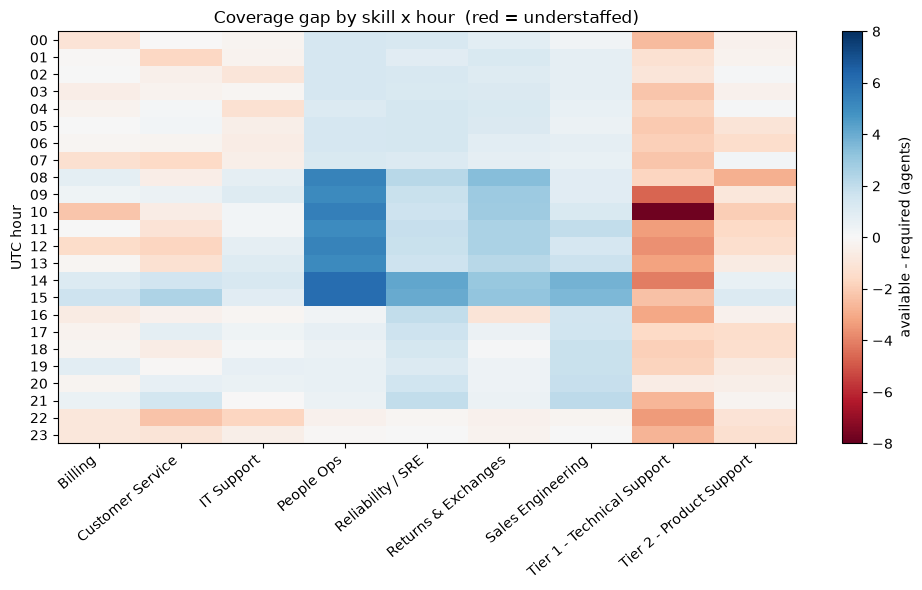

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(GAP.values, aspect='auto', cmap='RdBu', vmin=-8, vmax=8)
ax.set_yticks(range(24)); ax.set_yticklabels([f'{h:02d}' for h in range(24)])
ax.set_xticks(range(len(groups))); ax.set_xticklabels([gname[g] for g in groups], rotation=40, ha='right')
ax.set_ylabel('UTC hour'); ax.set_title('Coverage gap by skill x hour  (red = understaffed)')
plt.colorbar(im, label='available - required (agents)'); plt.tight_layout(); plt.show()

## Client exposure to understaffing
Rank clients by how much of their demand lands in understaffed skills — the optimizer should prioritize dedicated / high-priority clients here.

In [4]:
contracts = nbutils.load_contracts().set_index('organization_id')
deficit = (R.sum() - A.sum()).clip(lower=0)     # per-skill shortage (agents)
org_g = t.dropna(subset=['organization_id']).groupby(['organization_id','group_id']).size().rename('n').reset_index()
org_g['exposure'] = org_g['group_id'].map(deficit) * org_g['n']
risk = org_g.groupby('organization_id')['exposure'].sum().sort_values(ascending=False).head(10).to_frame()
risk['dedicated'] = [bool(contracts.loc[o,'dedicated']) if o in contracts.index else False for o in risk.index]
risk['client'] = [contracts.loc[o,'name'] if o in contracts.index else '' for o in risk.index]
risk.round(1)

,exposure,dedicated,client
organization_id,,,
800014,5431.1,True,IT C14 Ltd
800018,4766.7,True,IT C18 Ltd
800002,4752.8,True,IT C02 Ltd
800003,4706.4,True,IT C03 Ltd
800020,4616.5,True,IT C20 Ltd
800011,4598.3,True,IT C11 Ltd
800021,4592.6,True,IT C21 Ltd
800008,4483.3,True,IT C08 Ltd
800010,4387.2,True,IT C10 Ltd


In [5]:
# artifacts for Step 4 (optimizer)
GAP.stack().rename('gap').reset_index().rename(columns={'level_0':'hour','level_1':'group_id'})\
  .to_csv(nbutils.PROCESSED/'gap_by_skill_hour.csv', index=False)
tot.to_csv(nbutils.PROCESSED/'skill_totals.csv')
risk.to_csv(nbutils.PROCESSED/'client_risk.csv')
print('saved gap_by_skill_hour.csv, skill_totals.csv, client_risk.csv')
print('understaffed cells: %d/%d | net shortage (agent-hours): %.0f' % ((GAP<-0.5).sum().sum(), GAP.size, GAP[GAP<0].sum().sum()))

saved gap_by_skill_hour.csv, skill_totals.csv, client_risk.csv
understaffed cells: 60/216 | net shortage (agent-hours): -117


**Next → 04_optimizer:** a greedy reassignment that moves effective capacity from overstaffed skills/hours (People Ops, SRE, Returns) to understaffed ones (Tier 1/2 Technical Support), respecting skills, timezone and dedicated-client priority — then measure the coverage improvement.